# Exploratory Data Analysis (EDA)

## Objective

The purpose of this notebook is to explore the business performance of the Global E-Commerce dataset and discover meaningful insights using descriptive statistics and visualizations.

``Import Libraries``

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

```Load the Dataset```

In [4]:
df = pd.read_csv("../data/raw/ecommerce_dataset_+1m.csv", nrows=10000)
df.head(2)

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,return_reason,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date,product_id,product_name,category,sub_category,brand,product_rating_avg,product_reviews_count,stock_quantity,unit_price_usd,quantity,discount_percent,discount_amount_usd,total_price_usd,cost_usd,profit_usd,tax_usd,currency,payment_method,payment_status,installment_plan,shipping_method,shipping_cost_usd,delivery_days,shipping_country,warehouse_location,delivery_status,rating,review_sentiment,customer_feedback,coupon_used,coupon_code,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
0,ORD-XAJI0,2024-10-14 11:20:05.496679,2024,10,14,11,20,5,No,Completed,NaN,CUS-6DPBH,Drew Warren,Male,53,Regular,Netherlands,Utrecht,22.00,38,2022-04-23,PRD-1FPK,Coffee Maker Automatic,Home,Kitchen,Nike,3.20,3112,99,120.51,3,10,36.15,325.38,232.14,93.24,28.14,USD,Apple Pay,Paid,No,Economy,1.97,5,Netherlands,UK,In Transit,3,Neutral,NaN,Yes,CPN-ZBI,Email,Mobile,Search,52.10,13,No,45.30,28.66,Medium,Yes
1,ORD-NHJ7X,2024-10-21 00:49:44.681065,2024,10,21,0,49,44,No,Completed,NaN,CUS-G0FN9,Victor Sullivan,Male,61,Regular,United States,Los Angeles,82.20,21,2022-08-22,PRD-C6UZ,Yoga Mat Non-Slip,Health,Supplements,Asus,3.80,3758,146,60.33,2,15,18.10,102.56,67.78,34.78,8.96,USD,Bank Transfer,Paid,Yes,Next Day,5.48,3,United States,UK,Delivered,1,Negative,Good value for money,Yes,CPN-W2P,Google Ads,Desktop,Referral,36.20,15,No,97.10,33.91,Low,Yes


```Convert date columns```

In [5]:
date_columns = [
    "order_date",
    "account_creation_date"
]

for column in date_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors="coerce"
    )

In [6]:
df[date_columns].dtypes

order_date               datetime64[us]
account_creation_date    datetime64[us]
dtype: object

## 1. Analysis Dataset Overview

Before starting the business analysis, a short overview is created to confirm the size, date range, and number of unique business entities in the development dataset.


In [7]:
dataset_overview = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Unique Orders",
        "Unique Customers",
        "Unique Products",
        "First Order Date",
        "Latest Order Date"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["order_id"].nunique(),
        df["customer_id"].nunique(),
        df["product_id"].nunique(),
        df["order_date"].min(),
        df["order_date"].max()
    ]
})

dataset_overview

,Metric,Value
0,Total Records,10000
1,Total Columns,62
2,Unique Orders,9999
3,Unique Customers,10000
4,Unique Products,9971
5,First Order Date,2024-02-03 05:14:45.982917
6,Latest Order Date,2026-02-02 12:29:16.867113


## 2. Company Performance Overview

This section calculates the main Key Performance Indicators used to understand the overall performance of the e-commerce company.

The analysis compares all records with completed orders because pending, cancelled, processing, and returned orders may not represent successful sales.


In [8]:
df["order_status"].value_counts()

order_status
Completed     6986
Returned       993
Pending        985
Processing     525
Cancelled      511
Name: count, dtype: int64

```Create completed-orders data```

In [9]:
completed_orders = df[
    df["order_status"] == "Completed"
].copy()

In [10]:
print(f"All records: {len(df):,}")
print(f"Completed-order records: {len(completed_orders):,}")

All records: 10,000
Completed-order records: 6,986


```Calculate all-record KPIs```

In [11]:
all_total_revenue = df["total_price_usd"].sum()
all_total_profit = df["profit_usd"].sum()
all_total_orders = df["order_id"].nunique()
all_total_customers = df["customer_id"].nunique()
all_total_products = df["product_id"].nunique()
all_quantity_sold = df["quantity"].sum()

all_average_order_value = (
    all_total_revenue / all_total_orders
)

all_profit_margin = (
    all_total_profit / all_total_revenue
) * 100

```Calculate completed-order KPIs```

In [12]:
completed_total_revenue = completed_orders["total_price_usd"].sum()
completed_total_profit = completed_orders["profit_usd"].sum()
completed_total_orders = completed_orders["order_id"].nunique()
completed_total_customers = completed_orders["customer_id"].nunique()
completed_total_products = completed_orders["product_id"].nunique()
completed_quantity_sold = completed_orders["quantity"].sum()

completed_average_order_value = (
    completed_total_revenue / completed_total_orders
)

completed_profit_margin = (
    completed_total_profit / completed_total_revenue
) * 100

```Display company KPIs```


In [13]:
print("COMPANY PERFORMANCE — COMPLETED ORDERS")
print("-" * 50)

print(f"Total Revenue       : ${completed_total_revenue:,.2f}")
print(f"Total Profit        : ${completed_total_profit:,.2f}")
print(f"Total Orders        : {completed_total_orders:,}")
print(f"Total Customers     : {completed_total_customers:,}")
print(f"Unique Products     : {completed_total_products:,}")
print(f"Quantity Sold       : {completed_quantity_sold:,}")
print(f"Average Order Value : ${completed_average_order_value:,.2f}")
print(f"Profit Margin       : {completed_profit_margin:.2f}%")

COMPANY PERFORMANCE — COMPLETED ORDERS
--------------------------------------------------
Total Revenue       : $2,847,239.12
Total Profit        : $1,136,468.29
Total Orders        : 6,985
Total Customers     : 6,986
Unique Products     : 6,971
Quantity Sold       : 20,861
Average Order Value : $407.62
Profit Margin       : 39.91%


```Create a KPI comparison table```


In [14]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Unique Products",
        "Quantity Sold",
        "Average Order Value",
        "Profit Margin"
    ],
    "All Records": [
        all_total_revenue,
        all_total_profit,
        all_total_orders,
        all_total_customers,
        all_total_products,
        all_quantity_sold,
        all_average_order_value,
        all_profit_margin
    ],
    "Completed Orders": [
        completed_total_revenue,
        completed_total_profit,
        completed_total_orders,
        completed_total_customers,
        completed_total_products,
        completed_quantity_sold,
        completed_average_order_value,
        completed_profit_margin
    ]
})

kpi_summary

,KPI,All Records,Completed Orders
0,Total Revenue,"4,055,773.24","2,847,239.12"
1,Total Profit,"1,624,669.98","1,136,468.29"
2,Total Orders,"9,999.00","6,985.00"
3,Total Customers,"10,000.00","6,986.00"
4,Unique Products,"9,971.00","6,971.00"
5,Quantity Sold,"29,841.00","20,861.00"
6,Average Order Value,405.62,407.62
7,Profit Margin,40.06,39.91


```Calculate completion rate```


In [15]:
order_completion_rate = (
    completed_total_orders / all_total_orders
) * 100

print(f"Order Completion Rate: {order_completion_rate:.2f}%")

Order Completion Rate: 69.86%


```Order-status summary table```


In [16]:
order_status_summary = (
    df["order_status"]
    .value_counts()
    .rename_axis("Order Status")
    .reset_index(name="Number of Records")
)

order_status_summary["Percentage"] = (
    order_status_summary["Number of Records"]
    / order_status_summary["Number of Records"].sum()
    * 100
).round(2)

order_status_summary

,Order Status,Number of Records,Percentage
0,Completed,6986,69.86
1,Returned,993,9.93
2,Pending,985,9.85
3,Processing,525,5.25
4,Cancelled,511,5.11


```Visualize order statuses```


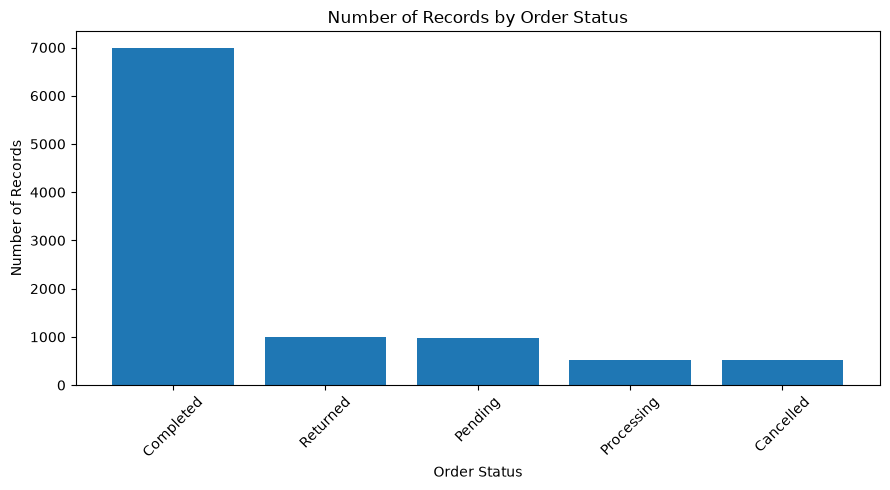

In [17]:
order_status_counts = df["order_status"].value_counts()

plt.figure(figsize=(9, 5))

plt.bar(
    order_status_counts.index,
    order_status_counts.values
)

plt.title("Number of Records by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/order_status_distribution.png")
plt.show()

### Business Observation

Completed orders represent approximately **69.86%** of all orders in the development sample.

The completed-order KPIs were used as the primary measure of business performance because cancelled, returned, pending, and processing orders do not necessarily represent successful sales.

The comparison between all records and completed orders highlights the importance of filtering data based on order status before calculating key business metrics such as revenue, profit, and average order value.

# 3. Sales Performance Analysis

The objective of this section is to evaluate the company's sales performance across different product categories. The analysis focuses on revenue, profitability, quantity sold, discounts, and customer ratings to identify high-performing and underperforming business segments.

In [18]:
df['category'].value_counts()

category
Health         2057
Clothing       2056
Electronics    1996
Sports         1974
Home           1917
Name: count, dtype: int64

```Which product category generates the highest revenue?```

In [19]:
category_revenue = (
    completed_orders.groupby("category")["total_price_usd"].sum().sort_values(ascending=False)
)

category_revenue

category
Electronics   993,305.34
Home          604,159.45
Sports        502,932.13
Health        409,496.35
Clothing      337,345.85
Name: total_price_usd, dtype: float64

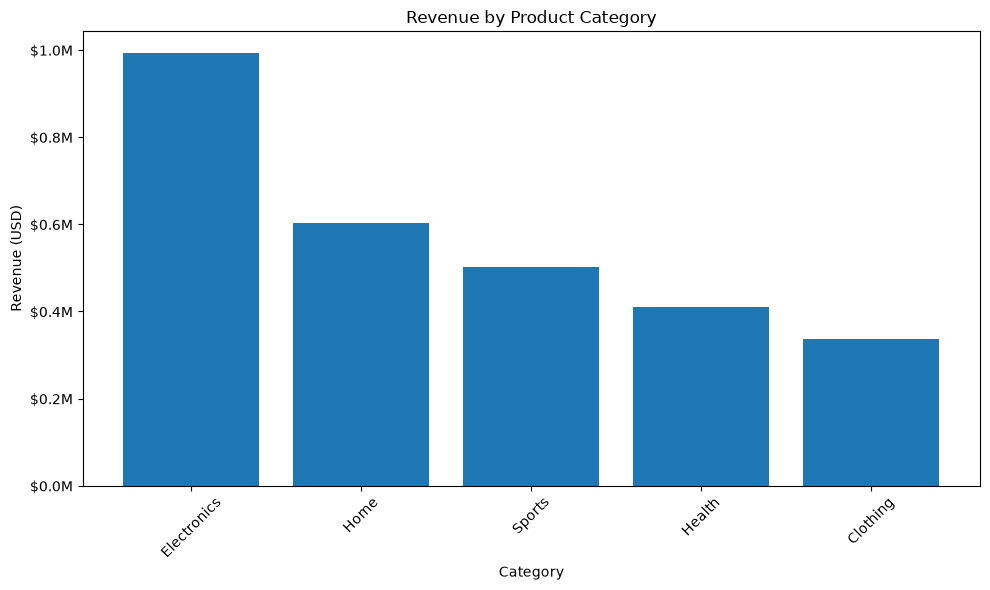

In [41]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"${value / 1_000_000:.1f}M")
)

plt.tight_layout()
plt.savefig("../images/category_revenue.png")
plt.show()

### Revenue Insight

Electronics generated the highest revenue among all product categories, contributing significantly more revenue than the remaining categories.

Although Electronics did not sell the highest number of units, its strong revenue performance suggests that products in this category have a higher average selling price.

```Which category generates the highest profit?```

In [23]:
category_profit = (
    completed_orders.groupby("category")["profit_usd"].sum().sort_values(ascending=False)
)
category_profit


category
Electronics   395,753.88
Home          243,418.92
Sports        202,336.90
Health        159,985.82
Clothing      134,972.77
Name: profit_usd, dtype: float64

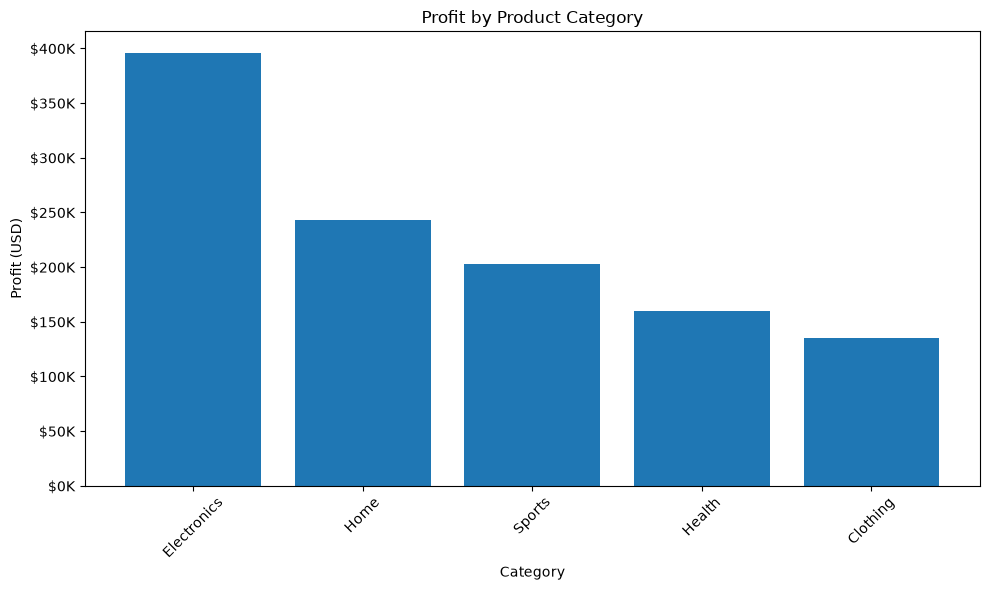

In [42]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit (USD)")
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"${value / 1_000:.0f}K")
)

plt.tight_layout()
plt.savefig("../images/category_profit.png")
plt.show()

### Profit Insight

Electronics generated the highest total profit, followed by Home and Sports.

The similarity between the revenue and profit rankings indicates that Electronics is not only the largest revenue contributor but also one of the most financially valuable categories for the business.

```Which category sells the most units?```

In [27]:
category_quantity = (
    completed_orders.groupby("category")["quantity"].sum().sort_values(ascending=False)
)
category_quantity

category
Clothing       4351
Health         4207
Electronics    4147
Sports         4082
Home           4074
Name: quantity, dtype: int64

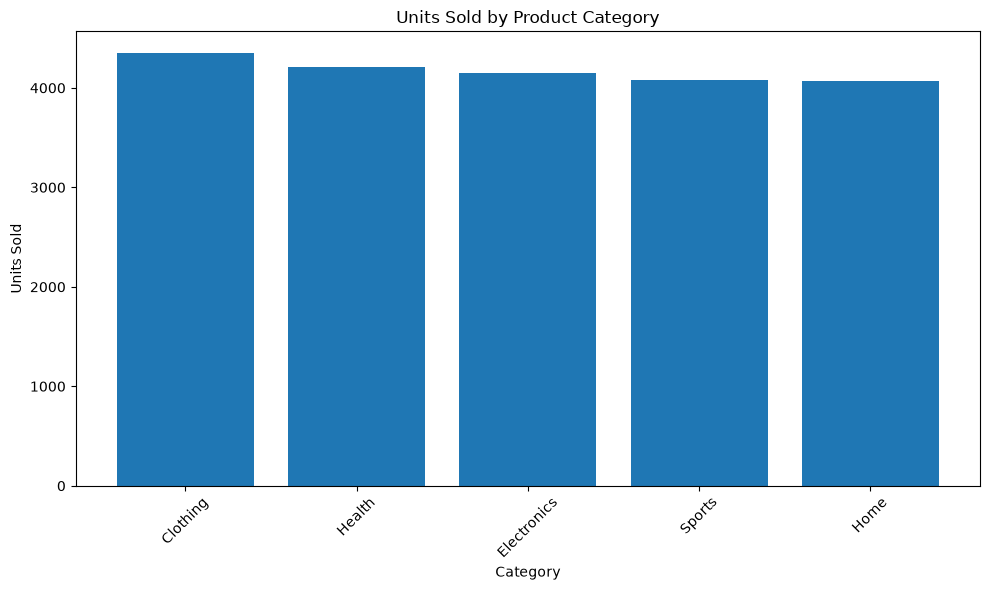

In [28]:
plt.figure(figsize=(10,6))
plt.bar(
    category_quantity.index,
    category_quantity.values
)

plt.title("Units Sold by Product Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/category_quantity.png")
plt.show()

### Quantity Sold Insight

Clothing recorded the highest number of units sold, despite generating the lowest revenue among the categories.

This indicates that Clothing products are likely lower-priced items, while Electronics generates substantially more revenue from a similar or lower sales volume.

```Which category gives the highest total discounts?```

In [29]:
category_discount = (
    completed_orders.groupby("category")["discount_amount_usd"].sum().sort_values(ascending=False)
    )
    
category_discount

category
Electronics   97,903.16
Home          55,453.08
Sports        43,833.90
Health        39,482.97
Clothing      29,838.26
Name: discount_amount_usd, dtype: float64

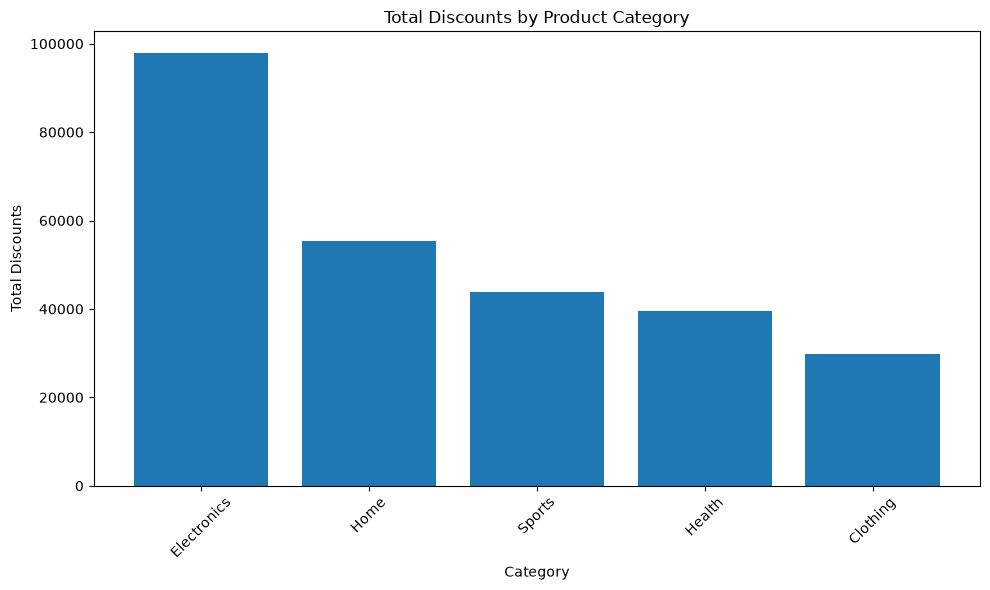

In [30]:
plt.figure(figsize=(10,6))
plt.bar(
    category_discount.index,
    category_discount.values
)

plt.title("Total Discounts by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Discounts")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/category_discount.png")
plt.show()


### Discount Insight

Electronics received the highest total discount amount among all categories.

However, because Electronics also generated the highest revenue, the larger discount total may be influenced by its higher product prices and sales value. A discount-rate analysis is required before concluding that Electronics is being over-discounted.

```Which category has the highest average customer rating?```


In [31]:
category_rating = (
    completed_orders.groupby("category")["rating"].mean().sort_values(ascending=False)
)
category_rating


category
Health        3.01
Sports        3.00
Electronics   2.99
Home          2.97
Clothing      2.96
Name: rating, dtype: float64

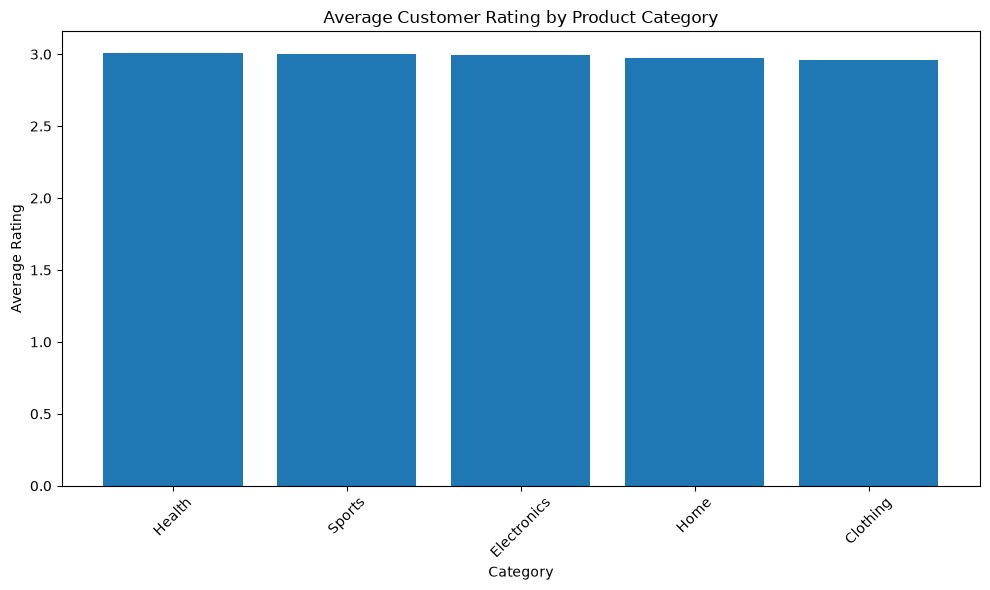

In [32]:
plt.figure(figsize=(10,6))
plt.bar(
    category_rating.index,
    category_rating.values
)

plt.title("Average Customer Rating by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/category_rating.png")
plt.show()


### Customer Rating Insight

Average customer ratings were close to 3 out of 5 across all product categories, with only minor differences between them.

No category demonstrated a clearly superior customer satisfaction level. The consistently moderate ratings may indicate opportunities to improve product quality, delivery experience, or after-sales service across the business.

```Which category has the highest profit margin?```


In [34]:
category_margin = (
completed_orders.groupby("category").agg({
    "profit_usd": "sum",
    "total_price_usd": "sum",
    })
)

category_margin["profit_margin"] = (category_margin["profit_usd"] / category_margin["total_price_usd"])*100

category_margin = category_margin.sort_values(by="profit_margin", ascending=False)
category_margin


,profit_usd,total_price_usd,profit_margin
category,,,
Home,"243,418.92","604,159.45",40.29
Sports,"202,336.90","502,932.13",40.23
Clothing,"134,972.77","337,345.85",40.01
Electronics,"395,753.88","993,305.34",39.84
Health,"159,985.82","409,496.35",39.07


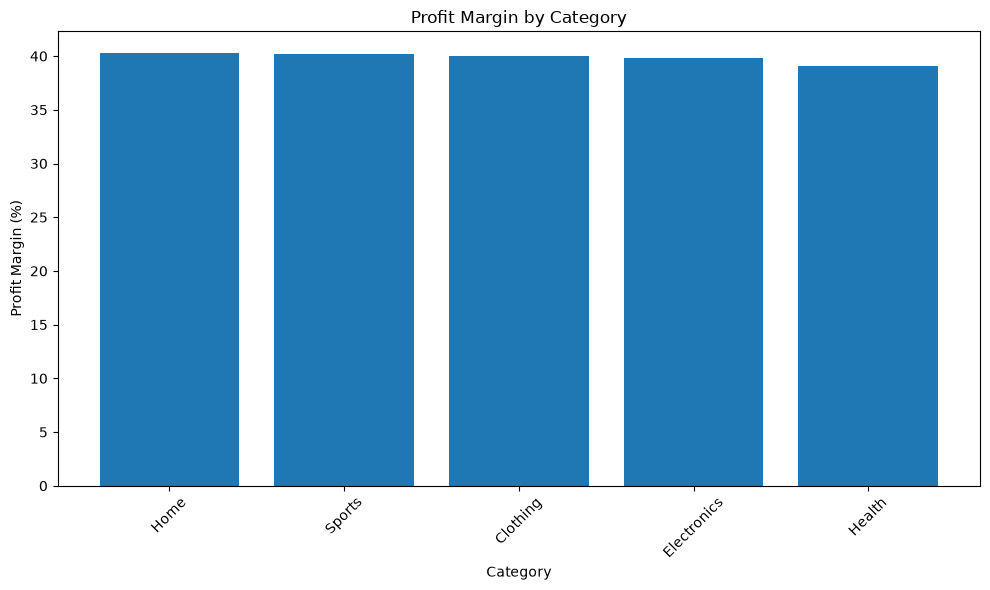

In [35]:
plt.figure(figsize=(10,6))

plt.bar(
    category_margin.index,
    category_margin["profit_margin"]
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/profit_margin_by_category.png")
plt.show()

### Profit Margin Insight

Profit margins remained close to 40% across all product categories, indicating relatively consistent profitability.

Home recorded the highest margin, while Health recorded the lowest. However, the difference was small, so there is no major category-level profitability gap in the current sample.

### Overall Category Performance Summary

Electronics is the strongest category in terms of both revenue and total profit, despite not having the highest sales volume. This suggests that its performance is driven mainly by higher-value products.

Clothing recorded the highest number of units sold but the lowest revenue and profit, indicating a lower average selling price per item.

Customer ratings and profit margins were relatively similar across categories. Therefore, the major difference in category performance appears to come from product pricing and total transaction value rather than major differences in customer satisfaction or profitability percentage.

```Average selling price per unit by product category```


In [38]:
category_average_price = (
    completed_orders
    .groupby("category")
    .agg(
        revenue=("total_price_usd", "sum"),
        units_sold=("quantity", "sum")
    )
)

category_average_price["average_revenue_per_unit"] = (
    category_average_price["revenue"]
    / category_average_price["units_sold"]
)

category_average_price = category_average_price.sort_values(
    "average_revenue_per_unit",
    ascending=False
)

category_average_price

,revenue,units_sold,average_revenue_per_unit
category,,,
Electronics,"993,305.34",4147,239.52
Home,"604,159.45",4074,148.30
Sports,"502,932.13",4082,123.21
Health,"409,496.35",4207,97.34
Clothing,"337,345.85",4351,77.53


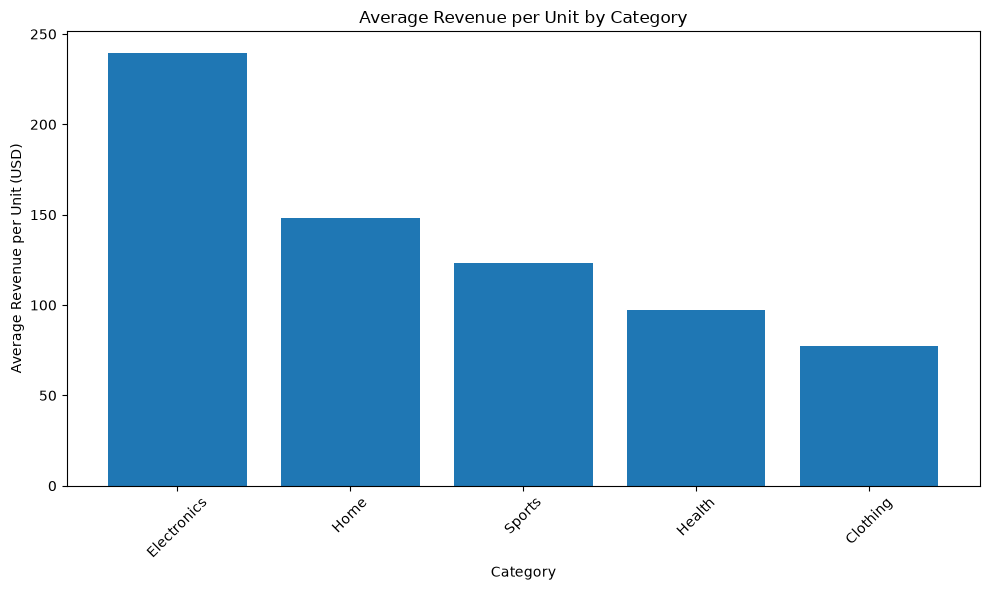

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_average_price.index,
    category_average_price["average_revenue_per_unit"]
)

plt.title("Average Revenue per Unit by Category")
plt.xlabel("Category")
plt.ylabel("Average Revenue per Unit (USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/category_average_price.png")
plt.show()